**SWE-Bench token cost (Codex / gpt-5.6-luna).** 300 selected SWE-Bench
tasks, four policies, one repeat. Scale bins are terciles of the
no-fault (clean-solve) token cost: short / medium / long, 100 tasks
each (cuts at 617k and 1.27M). Session tokens are the Codex usage for
that cell; temporal and whole-branch abort also rewrite independent
documents on every task (~40k extra replay tokens). (a) median session
tokens by scale; (b) paired median ratio versus the clean solve;
(c) token CDF; (d) per-repository median, repositories ordered by
clean-solve median. Line styles match the earlier FAST figures: gray
triangle = clean solve, red square = AgentTX causal, orange cross =
optimistic checkpoint, black hollow circle = whole-branch abort.


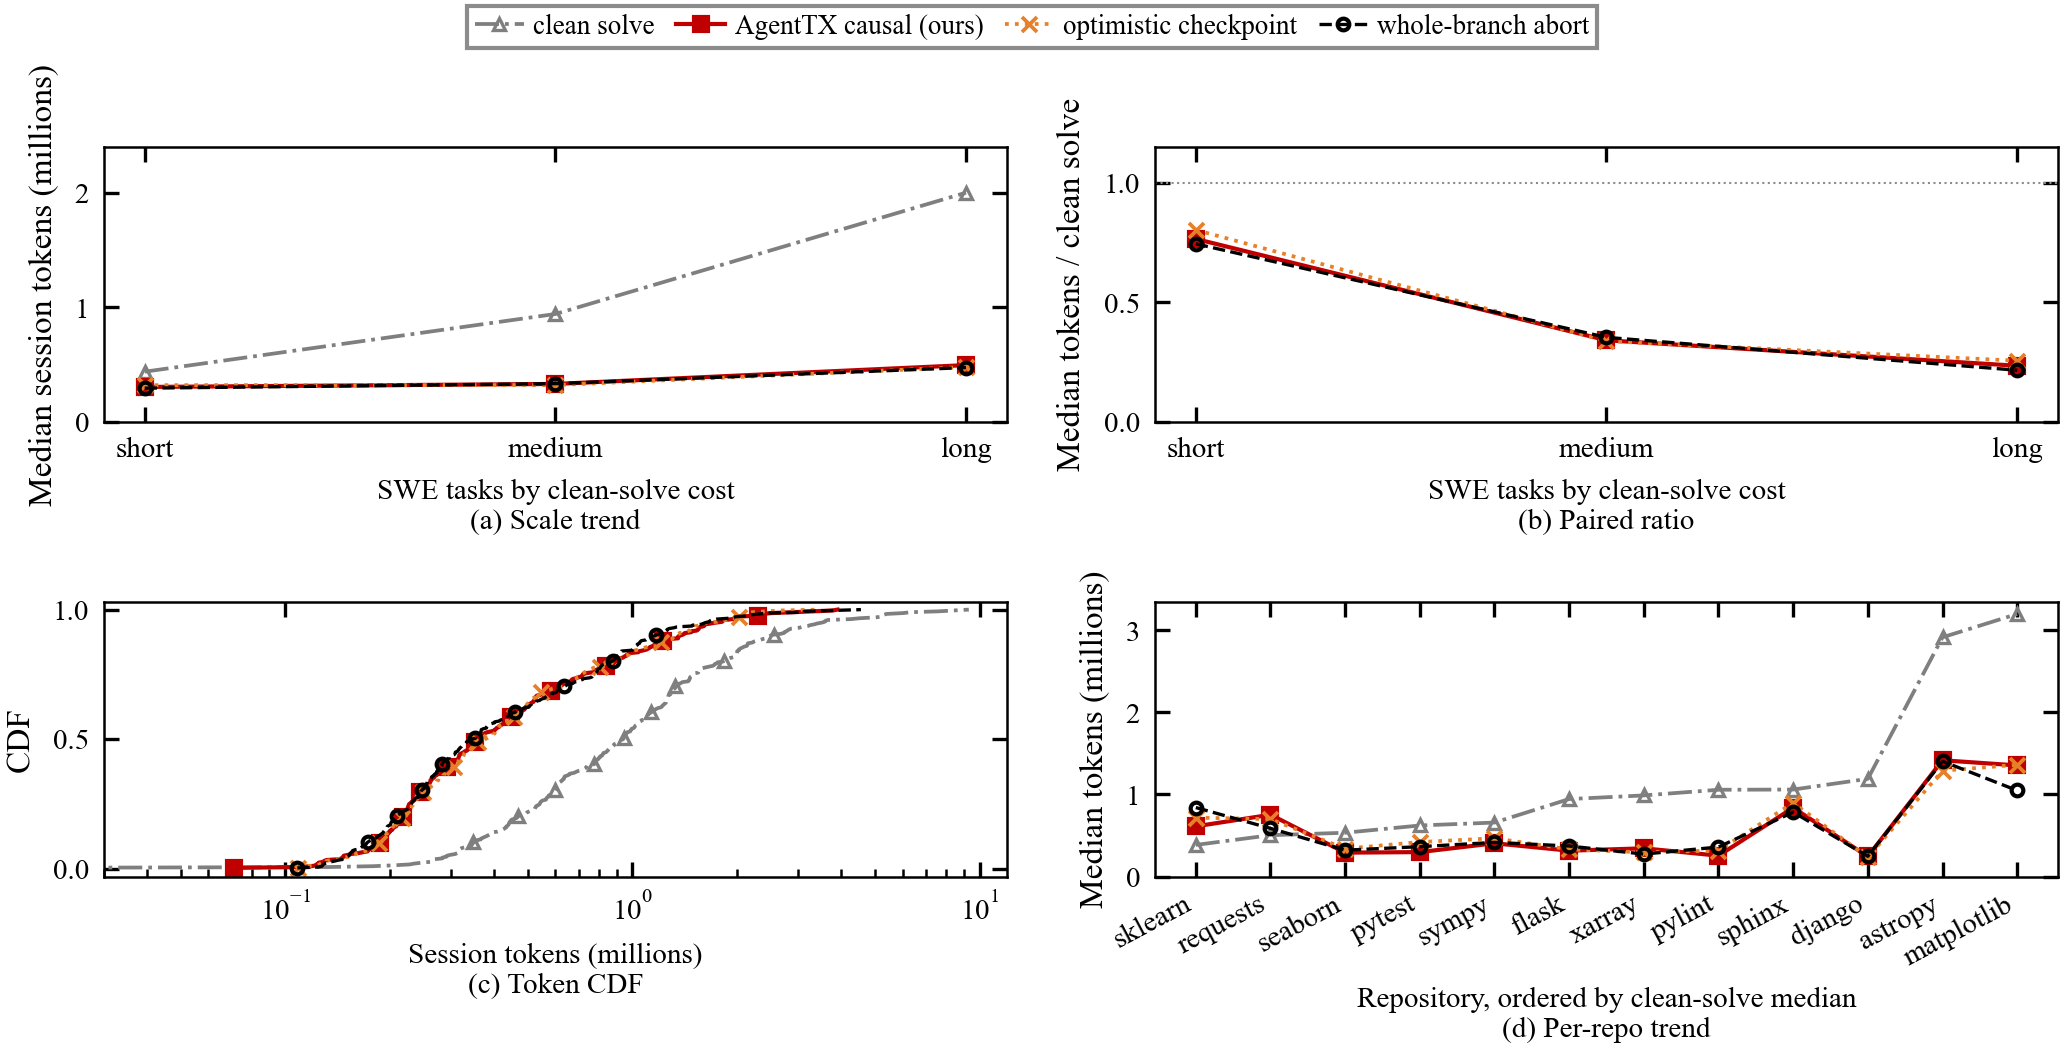

loaded C:\Users\big\osdi2026-agent-kernel\experiments\results\codex_7mode_full_r1_parallel_20260903\swe_official_tasks_raw.csv
tasks=300 cells=1200
tercile cuts (no_fault tokens):
            min      max     median  count
scale                                     
short     14599   616649   438491.5    100
medium   622245  1268419   942526.0    100
long    1274479  9307259  2002534.0    100
median tokens by scale (millions):
mode    no_fault  causal  temporal_checkpoint  whole_branch_abort
scale                                                            
short      0.438   0.305                0.321               0.295
medium     0.943   0.331                0.322               0.334
long       2.003   0.496                0.479               0.475
clean solve             : p50=  942.5k  mean= 1293.2k  charged_p50=  942.5k  replay_mean=  0.0k  success_p50=  944.5k
AgentTX causal (ours)   : p50=  354.9k  mean=  594.4k  charged_p50=  354.9k  replay_mean=  0.0k  success_p50=  336.1k
opti

In [1]:
# ipython -c "%run plot_swe_tokens.ipynb"
# FAST/USENIX line-plot conventions: white panels, boxed top legend,
# red solid squares = ours.
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")

STANDARD_WIDTH = 17.8  # USENIX two-column text width, cm


def cm_to_inch(value):
    return value / 2.54


plt.rcParams.update(plt.rcParamsDefault)
matplotlib.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Nimbus Roman", "Times New Roman", "Times"]
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.linewidth"] = 0.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.edgecolor"] = "0.55"
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.fancybox"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

STYLES = {
    "no_fault": dict(
        color="#7f7f7f",
        marker="^",
        linestyle="-.",
        linewidth=0.9,
        markersize=3.0,
        markerfacecolor="none",
        markeredgewidth=0.8,
    ),
    "causal": dict(color="#c00000", marker="s", linestyle="-", linewidth=1.0, markersize=3.2),
    "temporal_checkpoint": dict(
        color="#e78129",
        marker="x",
        linestyle=":",
        linewidth=0.9,
        markersize=3.6,
        markeredgewidth=0.9,
    ),
    "whole_branch_abort": dict(
        color="black",
        marker="o",
        linestyle="--",
        linewidth=0.8,
        markersize=2.8,
        markerfacecolor="none",
    ),
}
LABELS = {
    "no_fault": "clean solve",
    "causal": "AgentTX causal (ours)",
    "temporal_checkpoint": "optimistic checkpoint",
    "whole_branch_abort": "whole-branch abort",
}
MODES = list(STYLES)
REPO_SHORT = {
    "django/django": "django",
    "sympy/sympy": "sympy",
    "matplotlib/matplotlib": "matplotlib",
    "scikit-learn/scikit-learn": "sklearn",
    "pytest-dev/pytest": "pytest",
    "sphinx-doc/sphinx": "sphinx",
    "astropy/astropy": "astropy",
    "psf/requests": "requests",
    "pylint-dev/pylint": "pylint",
    "pydata/xarray": "xarray",
    "mwaskom/seaborn": "seaborn",
    "pallets/flask": "flask",
}

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "motivation" else cwd
FIGDIR = ROOT / "motivation"
PAPER = ROOT / "paper" / "img"
FIGDIR.mkdir(parents=True, exist_ok=True)
PAPER.mkdir(parents=True, exist_ok=True)

CSV_CANDIDATES = [
    ROOT / "experiments" / "results" / "codex_7mode_full_r1_parallel_20260903" / "swe_official_tasks_raw.csv",
    Path(r"C:\Users\big\osdi2026-agent-kernel\experiments\results\codex_7mode_full_r1_parallel_20260903\swe_official_tasks_raw.csv"),
]
CSV = next(path for path in CSV_CANDIDATES if path.exists())

df = pd.read_csv(CSV)
assert set(df["suite"].astype(str)) == {"swe"}
df["total_tokens"] = pd.to_numeric(df["total_tokens"], errors="coerce").fillna(0.0)
df["doc_replay_tokens"] = pd.to_numeric(df["doc_replay_tokens"], errors="coerce").fillna(0.0)
df["charged_tokens"] = df["total_tokens"] + df["doc_replay_tokens"]
df["success"] = df["success"].astype(str).str.lower().isin(["true", "1", "yes"])
df["repo_short"] = df["repo"].map(REPO_SHORT).fillna(df["repo"])

wide = (
    df.pivot_table(index=["task", "repo_short"], columns="mode", values="total_tokens", aggfunc="first")
    .reset_index()
    .sort_values("no_fault")
    .reset_index(drop=True)
)
wide["scale"] = pd.qcut(wide["no_fault"], 3, labels=["short", "medium", "long"])
SCALE_LABELS = ["short", "medium", "long"]
sx = np.arange(len(SCALE_LABELS))


def ecdf(values):
    values = np.asarray(values, dtype=float)
    values = values[values > 0]
    x = np.sort(values)
    y = np.arange(1, x.size + 1) / x.size
    return x, y


fig = plt.figure(dpi=300, figsize=(cm_to_inch(STANDARD_WIDTH), cm_to_inch(8.8)))
handles = []

ax = plt.subplot(2, 2, 1)
for mode in MODES:
    ys = [wide.loc[wide["scale"] == scale, mode].median() / 1e6 for scale in SCALE_LABELS]
    handle, = ax.plot(sx, ys, **STYLES[mode], label=LABELS[mode])
    handles.append(handle)
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 2.4)
ax.set_ylabel("Median session tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(a) Scale trend", fontsize=7)

ax = plt.subplot(2, 2, 2)
ax.axhline(1.0, color="0.55", linewidth=0.5, linestyle=":")
for mode in ("causal", "temporal_checkpoint", "whole_branch_abort"):
    ys = [
        (wide.loc[wide["scale"] == scale, mode] / wide.loc[wide["scale"] == scale, "no_fault"]).median()
        for scale in SCALE_LABELS
    ]
    ax.plot(sx, ys, **STYLES[mode])
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Median tokens / clean solve", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(b) Paired ratio", fontsize=7)

ax = plt.subplot(2, 2, 3)
for mode in MODES:
    tokens = df.loc[df["mode"] == mode, "total_tokens"].to_numpy(dtype=float)
    x, y = ecdf(tokens / 1e6)
    ax.plot(x, y, markevery=max(len(x) // 10, 1), **STYLES[mode])
ax.set_xscale("log")
ax.set_xlim(0.03, 12)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=5))
ax.set_ylim(-0.03, 1.03)
ax.set_ylabel("CDF", fontsize=8)
ax.set_xlabel("Session tokens (millions)\n(c) Token CDF", fontsize=7)

ax = plt.subplot(2, 2, 4)
repo_order = (
    df[df["mode"] == "no_fault"]
    .groupby("repo_short")["total_tokens"]
    .median()
    .sort_values()
    .index.tolist()
)
rx = np.arange(len(repo_order))
for mode in MODES:
    med = (
        df[df["mode"] == mode]
        .groupby("repo_short")["total_tokens"]
        .median()
        .reindex(repo_order)
        / 1e6
    )
    ax.plot(rx, med.to_numpy(dtype=float), **STYLES[mode])
ax.set_xticks(rx, repo_order, rotation=28, ha="right")
ax.set_ylabel("Median tokens (millions)", fontsize=8)
ax.set_xlabel("Repository, ordered by clean-solve median\n(d) Per-repo trend", fontsize=7)
ax.set_ylim(bottom=0)

for axis in fig.axes:
    axis.tick_params(axis="both", labelsize=7, direction="in", top=True, right=True)

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.035),
    ncol=4,
    fontsize=6.5,
    columnspacing=0.8,
    handlelength=1.8,
    handletextpad=0.35,
    borderpad=0.3,
)
plt.tight_layout(pad=0.6, h_pad=1.6, w_pad=1.2, rect=[0.0, 0.0, 1.0, 0.91])
for dest in (FIGDIR, PAPER):
    fig.savefig(dest / "FIG-SWE-Tokens.pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(dest / "FIG-SWE-Token-Tasks.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
if matplotlib.get_backend().lower() != "agg":
    plt.show()

print(f"loaded {CSV}")
print(f"tasks={wide.shape[0]} cells={len(df)}")
print("tercile cuts (no_fault tokens):")
print(wide.groupby("scale", observed=False)["no_fault"].agg(["min", "max", "median", "count"]).to_string())
print("median tokens by scale (millions):")
print((wide.groupby("scale", observed=False)[MODES].median() / 1e6).round(3).to_string())
for mode in MODES:
    rows = df[df["mode"] == mode]
    tok = rows["total_tokens"]
    charged = rows["charged_tokens"]
    replay = rows["doc_replay_tokens"]
    ok = rows.loc[rows["success"], "total_tokens"]
    print(
        f"{LABELS[mode]:24s}: p50={tok.median()/1e3:7.1f}k  "
        f"mean={tok.mean()/1e3:7.1f}k  charged_p50={charged.median()/1e3:7.1f}k  "
        f"replay_mean={replay.mean()/1e3:5.1f}k  success_p50={ok.median()/1e3:7.1f}k"
    )
for mode in ("causal", "temporal_checkpoint", "whole_branch_abort"):
    ratio = (wide[mode] / wide["no_fault"]).replace([np.inf, -np.inf], np.nan).dropna()
    print(
        f"ratio {LABELS[mode]:24s} / clean: "
        f"p50={ratio.median():.3f}  mean={ratio.mean():.3f}  "
        f"cheaper={(ratio < 1).mean():.1%}"
    )
